# Embryo Diffusion — Phase‑Guided (silver F0) & Optional Classifier Guidance

This notebook trains a **conditional diffusion model** on the *silver* dataset (`data/embryo_dataset_silver/F0`) using the project's new structure. It conditions on the **morphokinetic phase** and supports **optional guidance** at sampling time using your pretrained **phase classifier** (external classifier guidance).  

**Project structure assumptions** (edit paths in the next cell if needed):
```
thesis/
├── data/
│   ├── embryo_dataset_bronze/                 # raw frames (unused here)
│   └── embryo_dataset_silver/
│       └── F0/
│           └── <embryo_id>/
│               ├── 00001.jpg, 00002.jpg, ...  # preprocessed frames (presence-filtered)
│               └── <embryo_id>_phases.csv     # copied unchanged
├── preprocessing/
│   └── embryo_presence_models/
├── classifier/
│   └── embryo_phase_models/
└── diffusion/
    ├── train_diffusion.ipynb                  # ← this notebook (recommended location)
    ├── embryo_diffusion_models/               # checkpoints
    └── diffusion_samples/                     # generated samples
```

**Notes**
- We **do not** run presence filtering here; *silver* data is already filtered by your preprocessing pipeline.
- Training uses pairs \((x_t, x_{t+\Delta})\) within each embryo sequence, with phases read from `<embryo_id>_phases.csv`.
- The UNet is **phase‑conditioned** (classifier‑free guidance during training/sampling).  
- Optionally, you can enable **external classifier guidance** at sampling using your phase classifier in `classifier/embryo_phase_models/`. If it fails to load, sampling gracefully falls back to classifier‑free guidance.


In [1]:
# ==== CONFIG (edit if needed) ====
from pathlib import Path
import os

# If you open this notebook from thesis/diffusion/, PROJECT_ROOT points there
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name != 'diffusion':
    # try to infer if opened from repo root
    if (PROJECT_ROOT / 'diffusion').exists():
        PROJECT_ROOT = PROJECT_ROOT / 'diffusion'

DATA_ROOT = PROJECT_ROOT.parent / 'data'
SILVER_F0_ROOT = DATA_ROOT / 'embryo_dataset_silver' / 'F0'
PHASE_CSV_AT_SILVER = True  # phases CSV lives next to frames in silver

# Models
PHASE_MODEL_DIR = PROJECT_ROOT.parent / 'classifier' / 'embryo_phase_models'
PHASE_MODEL_PATH = None  # autodetected if None

# Outputs
OUT_MODELS_DIR = PROJECT_ROOT / 'embryo_diffusion_models'
OUT_SAMPLES_DIR = PROJECT_ROOT / 'diffusion_samples'
CACHE_DIR = PROJECT_ROOT / 'cache'
for d in (OUT_MODELS_DIR, OUT_SAMPLES_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Training
IMG_SIZE = 256           # images are 500x500 in dataset; we center-crop & resize
BATCH_SIZE = 8
LR = 2e-4
EPOCHS = 20
NUM_WORKERS = 4
GRAD_ACCUM = 1
VAL_SPLIT = 0.05
MAX_SAMPLES_PER_EMBRYO = 150
DELTA_MIN = 1
DELTA_MAX = 5

# Diffusion
TIMESTEPS = 1000
BETA_START, BETA_END = 1e-4, 2e-2
GUIDANCE_PROB = 0.9     # classifier-free guidance dropout during training
GUIDANCE_SCALE = 2.0    # CFG scale at sampling

# External classifier guidance (optional). If True and a classifier loads, use gradient guidance at sampling.
USE_CLASSIFIER_GUIDANCE = True
CLASSIFIER_GUIDANCE_SCALE = 1.5  # strength for external classifier guidance step
CLASSIFIER_INPUT_SIZE = 256      # if your classifier expects another size, change this

print('Project root:', PROJECT_ROOT)
print('Silver F0 root:', SILVER_F0_ROOT)
assert SILVER_F0_ROOT.exists(), f"Silver F0 folder not found: {SILVER_F0_ROOT}"


Project root: /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/diffusion
Silver F0 root: /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/data/embryo_dataset_silver/F0


In [2]:
# Imports & utils
import math, random, glob
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

PHASE_LABELS = ['pPB2','pPNa','pPNf','p2','p3','p4','p5','p6','p7','p8','p9+','pM','pSB','pB','pEB','pHB']
NUM_PHASES = len(PHASE_LABELS)

def load_image(path: str, size: int = IMG_SIZE):
    img = Image.open(path).convert('L')
    # center-crop square then resize
    w, h = img.size
    m = min(w, h)
    left = (w - m) // 2
    top = (h - m) // 2
    img = img.crop((left, top, left + m, top + m))
    if size is not None and (img.size[0] != size or img.size[1] != size):
        img = img.resize((size, size), Image.BICUBIC)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = arr * 2 - 1  # [-1, 1]
    return torch.from_numpy(arr).unsqueeze(0)

def denorm(x):
    return (x.clamp(-1,1) + 1) / 2


Using device: cuda


In [3]:
# Build frame index from silver F0: phase CSV lives next to frames
INDEX_CACHE = CACHE_DIR / 'silver_f0_frame_index.csv'

def build_index_from_silver():
    rows = []
    embryo_ids = sorted([d.name for d in SILVER_F0_ROOT.iterdir() if d.is_dir()])
    for eid in tqdm(embryo_ids, desc='Indexing embryos (silver F0)'):
        folder = SILVER_F0_ROOT / eid
        ann_path = folder / f"{eid}_phases.csv"
        if not ann_path.exists():
            continue
        # Use jpg/jpeg/png
        img_files = sorted(glob.glob(str(folder / '*.jpg'))) or \
                    sorted(glob.glob(str(folder / '*.jpeg'))) or \
                    sorted(glob.glob(str(folder / '*.png')))
        if not img_files:
            continue
        # read CSV (phase, start, end)
        df = pd.read_csv(ann_path, header=None, names=['phase','start','end'], sep='[,;\s]+', engine='python')
        def phase_to_id(ph: str):
            ph = str(ph).strip()
            ph = ph.replace('t','p',1) if ph.startswith('t') else ph  # accept t* or p*
            return PHASE_LABELS.index(ph)
        label_spans = []
        for _, r in df.iterrows():
            try:
                pid = phase_to_id(r['phase'])
                label_spans.append((int(r['start']), int(r['end']), pid))
            except Exception:
                pass
        # assign phase per frame (keep frames >= first event)
        for i, f in enumerate(img_files):
            pid = None
            for s,e,p in label_spans:
                if s <= i+1 <= e:  # silver keeps original 1-based indices in filenames; our i is 0-based list index
                    pid = p
                    break
            if pid is None:
                continue
            rows.append({'embryo_id': eid, 'frame_idx': i+1, 'path': f, 'phase_id': pid})
    return pd.DataFrame(rows)

if INDEX_CACHE.exists():
    index_df = pd.read_csv(INDEX_CACHE)
else:
    index_df = build_index_from_silver()
    index_df.to_csv(INDEX_CACHE, index=False)

print('Indexed frames:', len(index_df))
index_df.head()


Indexing embryos (silver F0): 100%|██████████| 704/704 [00:11<00:00, 61.20it/s]


Indexed frames: 289128


,embryo_id,frame_idx,path,phase_id
0,AA83-7,5,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,0
1,AA83-7,6,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,0
2,AA83-7,7,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,0
3,AA83-7,8,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,0
4,AA83-7,9,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,0


In [4]:
# Build training pairs (x_t -> x_{t+Δ}) within each embryo, only using indexed frames
PAIRS_CACHE = CACHE_DIR / f'pairs_silver_d{DELTA_MIN}-{DELTA_MAX}_max{MAX_SAMPLES_PER_EMBRYO}.csv'

def build_pairs(df: pd.DataFrame, delta_min=DELTA_MIN, delta_max=DELTA_MAX, max_samples_per_embryo=MAX_SAMPLES_PER_EMBRYO):
    pairs = []
    by_embryo = df.groupby('embryo_id')
    for eid, g in tqdm(by_embryo, desc='Sampling pairs per embryo'):
        g = g.sort_values('frame_idx')
        files = g['path'].tolist()
        phases = g['phase_id'].tolist()
        n = len(files)
        if n < delta_min + 1:
            continue
        cnt = 0
        tries = 0
        while cnt < max_samples_per_embryo and tries < max(1000, 5*max_samples_per_embryo):
            tries += 1
            i = random.randrange(0, n-1)
            d = random.randint(delta_min, min(delta_max, n-1-i))
            j = i + d
            pairs.append({'embryo_id': eid,
                          'src_path': files[i], 'tgt_path': files[j],
                          'src_phase': int(phases[i]), 'tgt_phase': int(phases[j])})
            cnt += 1
    return pd.DataFrame(pairs)

if PAIRS_CACHE.exists():
    pairs_df = pd.read_csv(PAIRS_CACHE)
else:
    pairs_df = build_pairs(index_df)
    pairs_df.to_csv(PAIRS_CACHE, index=False)

print('Total training pairs:', len(pairs_df))
pairs_df.head()


Sampling pairs per embryo: 100%|██████████| 703/703 [00:00<00:00, 5174.12it/s]


Total training pairs: 105450


,embryo_id,src_path,tgt_path,src_phase,tgt_phase
0,AA83-7,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,1,1
1,AA83-7,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,3,3
2,AA83-7,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,3,3
3,AA83-7,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,1,1
4,AA83-7,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,/mnt/c/Users/ioann/OneDrive/Documents/Projects...,1,1


In [5]:
# Split by embryo_id to avoid leakage
embryos = pairs_df['embryo_id'].unique().tolist()
random.shuffle(embryos)
val_count = max(1, int(len(embryos) * VAL_SPLIT))
val_embryos = set(embryos[:val_count])
train_df = pairs_df[~pairs_df['embryo_id'].isin(val_embryos)].reset_index(drop=True)
val_df   = pairs_df[pairs_df['embryo_id'].isin(val_embryos)].reset_index(drop=True)
print(f'Embryos total={len(embryos)}, train={len(embryos)-val_count}, val={val_count}')
print('Train pairs:', len(train_df), 'Val pairs:', len(val_df))


Embryos total=703, train=668, val=35
Train pairs: 100200 Val pairs: 5250


In [6]:
class PairDataset(Dataset):
    def __init__(self, df):
        self.df = df
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x_src = load_image(row['src_path'])
        x_tgt = load_image(row['tgt_path'])
        return x_src, x_tgt, int(row['src_phase']), int(row['tgt_phase'])

train_loader = DataLoader(PairDataset(train_df), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(PairDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)


In [7]:
# Diffusion schedule
def make_beta_schedule(timesteps=TIMESTEPS, beta_start=BETA_START, beta_end=BETA_END):
    return torch.linspace(beta_start, beta_end, timesteps)

betas = make_beta_schedule()
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0]), alphas_cumprod[:-1]], dim=0)

to_dev = lambda t: t.to(device).float()
betas = to_dev(betas); alphas = to_dev(alphas); alphas_cumprod = to_dev(alphas_cumprod); alphas_cumprod_prev = to_dev(alphas_cumprod_prev)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)


/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5080 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5080 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [8]:
# UNet with phase conditioning + classifier-free guidance
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_emb_ch, cond_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time = nn.Linear(t_emb_ch, out_ch)
        self.cond = nn.Linear(cond_ch, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb, c_emb):
        h = self.conv1(F.silu(x))
        h = h + self.time(F.silu(t_emb))[:,:,None,None] + self.cond(F.silu(c_emb))[:,:,None,None]
        h = self.conv2(F.silu(h))
        return h + self.skip(x)

def timestep_embedding(timesteps, dim=128):
    half = dim//2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, dtype=torch.float32, device=timesteps.device) / (half-1))
    args = timesteps.float()[:, None] * freqs[None]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
    return emb

class UNetCond(nn.Module):
    def __init__(self, in_ch=1, base=64, t_emb_dim=128, cond_dim=128, num_classes=NUM_PHASES):
        super().__init__()
        self.class_emb = nn.Embedding(num_classes+1, cond_dim)  # +1 null token for CFG
        self.null_class = num_classes
        self.t_mlp = nn.Sequential(nn.Linear(t_emb_dim, t_emb_dim), nn.SiLU(), nn.Linear(t_emb_dim, t_emb_dim))
        self.c_mlp = nn.Sequential(nn.Linear(cond_dim, cond_dim), nn.SiLU(), nn.Linear(cond_dim, cond_dim))
        self.inp = nn.Conv2d(in_ch, base, 3, padding=1)
        self.rb1 = ResBlock(base, base, t_emb_dim, cond_dim)
        self.down1 = nn.Conv2d(base, base*2, 4, stride=2, padding=1)
        self.rb2 = ResBlock(base*2, base*2, t_emb_dim, cond_dim)
        self.down2 = nn.Conv2d(base*2, base*4, 4, stride=2, padding=1)
        self.rb3 = ResBlock(base*4, base*4, t_emb_dim, cond_dim)
        self.mid = ResBlock(base*4, base*4, t_emb_dim, cond_dim)
        self.up1 = nn.ConvTranspose2d(base*4, base*2, 4, stride=2, padding=1)
        self.rb4 = ResBlock(base*2, base*2, t_emb_dim, cond_dim)
        self.up2 = nn.ConvTranspose2d(base*2, base, 4, stride=2, padding=1)
        self.rb5 = ResBlock(base, base, t_emb_dim, cond_dim)
        self.out = nn.Conv2d(base, in_ch, 3, padding=1)
    def forward(self, x, t, cls):
        t_emb = timestep_embedding(t, dim=128)
        t_emb = self.t_mlp(t_emb)
        c_emb = self.class_emb(cls.clamp(0, self.class_emb.num_embeddings-1))
        c_emb = self.c_mlp(c_emb)
        h = self.inp(x)
        h1 = self.rb1(h, t_emb, c_emb)
        h2 = self.rb2(self.down1(h1), t_emb, c_emb)
        h3 = self.rb3(self.down2(h2), t_emb, c_emb)
        hmid = self.mid(h3, t_emb, c_emb)
        u1 = self.rb4(self.up1(hmid), t_emb, c_emb) + h2
        u2 = self.rb5(self.up2(u1), t_emb, c_emb) + h1
        out = self.out(F.silu(u2))
        return out

class DiffusionCond(nn.Module):
    def __init__(self, model: UNetCond, timesteps=TIMESTEPS):
        super().__init__()
        self.model = model
        self.timesteps = timesteps
    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_alpha = sqrt_alphas_cumprod[t][:,None,None,None]
        sqrt_one_minus = sqrt_one_minus_alphas_cumprod[t][:,None,None,None]
        return sqrt_alpha * x0 + sqrt_one_minus * noise, noise
    def p_losses(self, x0, cond_cls):
        B = x0.size(0)
        t = torch.randint(0, self.timesteps, (B,), device=x0.device, dtype=torch.long)
        x_noisy, noise = self.q_sample(x0, t)
        # classifier-free guidance dropout
        use_cond = (torch.rand(B, device=x0.device) < GUIDANCE_PROB).long()
        cls_in = cond_cls.clone()
        cls_in[use_cond==0] = self.model.null_class
        pred = self.model(x_noisy, t, cls_in)
        return F.mse_loss(pred, noise)
    @torch.no_grad()
    def p_sample_cfg(self, x, t, cls, guidance_scale=GUIDANCE_SCALE):
        null = torch.full_like(cls, self.model.null_class)
        eps_cond = self.model(x, t, cls)
        eps_null = self.model(x, t, null)
        eps = eps_null + guidance_scale * (eps_cond - eps_null)
        beta_t = betas[t][:,None,None,None]
        sqrt_one_minus = sqrt_one_minus_alphas_cumprod[t][:,None,None,None]
        sqrt_recip = sqrt_recip_alphas[t][:,None,None,None]
        mean = sqrt_recip * (x - beta_t / sqrt_one_minus * eps)
        noise = torch.randn_like(x) if t.min() > 0 else torch.zeros_like(x)
        var = posterior_variance[t][:,None,None,None]
        return mean + torch.sqrt(var) * noise
    def sample(self, shape, cls, guidance_scale=GUIDANCE_SCALE, classifier=None, classifier_scale=CLASSIFIER_GUIDANCE_SCALE):
        B = shape[0]
        x = torch.randn(shape, device=device)
        for i in reversed(range(self.timesteps)):
            t = torch.full((B,), i, device=device, dtype=torch.long)
            x = self.p_sample_cfg(x, t, cls, guidance_scale)
            # Optional: external classifier guidance (nudges x by grad of log p(y|x))
            if classifier is not None:
                x.requires_grad_(True)
                logits = classifier(x)
                # target class log prob
                logp = F.log_softmax(logits, dim=1)[torch.arange(B, device=x.device), cls]
                loss = -logp.mean()
                g = torch.autograd.grad(loss, x, retain_graph=False)[0]
                x = (x - classifier_scale * g).detach()
        return x


In [9]:
# Try to auto-detect a phase classifier checkpoint
def autodetect_model(model_dir: Path, keywords=('phase','classifier','model','.pt','.pth','.ckpt','.jit')):
    if not model_dir.exists():
        return None
    cands = []
    for p in model_dir.glob('**/*'):
        name = p.name.lower()
        if p.is_file() and any(k in name for k in keywords):
            cands.append(p)
    if cands:
        cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
        return cands[0]
    return None

if PHASE_MODEL_PATH is None:
    PHASE_MODEL_PATH = autodetect_model(PHASE_MODEL_DIR)
print('Phase classifier candidate:', PHASE_MODEL_PATH)

# We don't know your exact classifier class; we attempt a few robust load paths.
phase_classifier = None
phase_classifier_input_resize = CLASSIFIER_INPUT_SIZE

def _resize_for_classifier(x):
    # x: [B,1,H,W] in [-1,1] → resize to CLASSIFIER_INPUT_SIZE and normalize if needed
    if x.shape[-1] != phase_classifier_input_resize:
        x = F.interpolate(x, size=(phase_classifier_input_resize, phase_classifier_input_resize), mode='bilinear', align_corners=False)
    return x

if PHASE_MODEL_PATH is not None and USE_CLASSIFIER_GUIDANCE:
    try:
        # 1) TorchScript
        phase_classifier = torch.jit.load(str(PHASE_MODEL_PATH), map_location=device)
        phase_classifier.eval()
    except Exception:
        try:
            # 2) Full nn.Module saved in checkpoint
            obj = torch.load(PHASE_MODEL_PATH, map_location=device)
            if isinstance(obj, nn.Module):
                phase_classifier = obj
                phase_classifier.eval()
            elif isinstance(obj, dict) and 'model' in obj and isinstance(obj['model'], nn.Module):
                phase_classifier = obj['model']
                phase_classifier.eval()
            else:
                phase_classifier = None
        except Exception:
            phase_classifier = None

if phase_classifier is not None:
    # wrap to accept [-1,1] grayscale and return logits [B, NUM_PHASES]
    class PhaseClassifierWrapper(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
        def forward(self, x):
            x = _resize_for_classifier(x)
            # if the classifier expects 3ch, replicate
            if getattr(self.model, 'in_channels', 1) == 3 or any(getattr(m, 'in_channels', 1)==3 for m in self.model.modules() if hasattr(m,'in_channels')):
                x = x.repeat(1,3,1,1)
            # many classifiers expect mean/std normalization in [0,1]
            x01 = denorm(x)
            return self.model(x01)
    phase_classifier = PhaseClassifierWrapper(phase_classifier).to(device)
    print('Phase classifier loaded for external guidance.')
else:
    print('Phase classifier not available or failed to load. External guidance will be disabled.')


Phase classifier candidate: /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/classifier/embryo_phase_models/phase_classifier_efficientnet_f1=642.pth


/tmp/ipykernel_19682/3288174505.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(PHASE_MODEL_PATH, map_location=device)


Phase classifier loaded for external guidance.


In [10]:
# Train loop
model = UNetCond(in_ch=1, base=64, num_classes=NUM_PHASES).to(device)
diffusion = DiffusionCond(model, timesteps=TIMESTEPS).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

best_val = None
ckpt_path = OUT_MODELS_DIR / f'phase_guided_ddpm_{IMG_SIZE}px.pt'

def one_epoch(loader, train=True):
    model.train(mode=train)
    total = 0.0
    count = 0
    for x_src, x_tgt, src_phase, tgt_phase in tqdm(loader):
        x_tgt = x_tgt.to(device, non_blocking=True)
        cond_cls = torch.tensor(tgt_phase, device=device, dtype=torch.long)
        loss = diffusion.p_losses(x_tgt, cond_cls)
        if train:
            loss.backward()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
        total += loss.item() * x_tgt.size(0)
        count += x_tgt.size(0)
    return total / max(1, count)

for epoch in range(1, EPOCHS+1):
    tl = one_epoch(train_loader, train=True)
    with torch.no_grad():
        vl = one_epoch(val_loader, train=False)
    print(f"[Epoch {epoch:03d}] train {tl:.4f} | val {vl:.4f}")
    if best_val is None or vl < best_val:
        best_val = vl
        torch.save({'model': model, 'epoch': epoch, 'val_loss': vl, 'config': {
            'IMG_SIZE': IMG_SIZE, 'TIMESTEPS': TIMESTEPS, 'PHASE_LABELS': PHASE_LABELS
        }}, ckpt_path)
        print('Saved best to', ckpt_path)


  0%|          | 0/12525 [00:00<?, ?it/s]/tmp/ipykernel_19682/890842386.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cond_cls = torch.tensor(tgt_phase, device=device, dtype=torch.long)
100%|██████████| 657/657 [00:38<00:00, 16.92it/s]


[Epoch 001] train 0.0254 | val 0.0179
Saved best to /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/diffusion/embryo_diffusion_models/phase_guided_ddpm_256px.pt


100%|██████████| 657/657 [00:35<00:00, 18.63it/s]


[Epoch 002] train 0.0193 | val 0.0178
Saved best to /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/diffusion/embryo_diffusion_models/phase_guided_ddpm_256px.pt


 25%|██▌       | 3191/12525 [07:14<21:09,  7.35it/s]  


KeyboardInterrupt: 

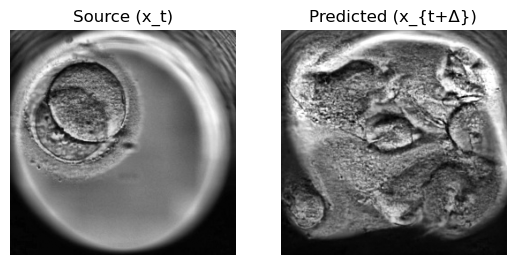

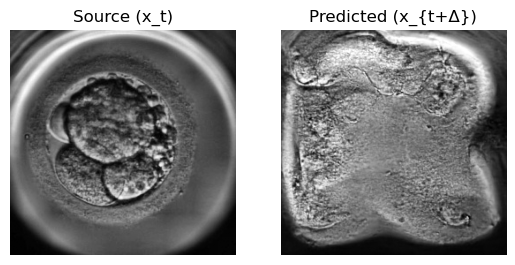

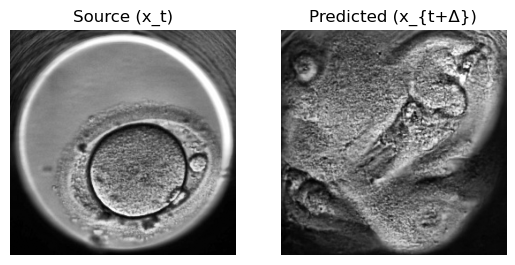

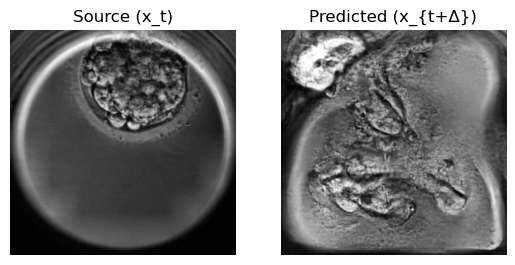

In [13]:
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_samples(num=4, use_classifier_guidance: bool = True):
    samp = val_df.sample(n=min(num, len(val_df))).reset_index(drop=True)
    for i in range(len(samp)):
        row = samp.iloc[i]
        x_src = load_image(row['src_path']).to(device)[None]
        tgt_cls = torch.tensor([int(row['tgt_phase'])], device=device, dtype=torch.long)
        clf = phase_classifier if (use_classifier_guidance and phase_classifier is not None and USE_CLASSIFIER_GUIDANCE) else None
        # If external classifier guidance is requested, temporarily enable grad for sampling only
        if clf is not None:
            with torch.enable_grad():
                x_gen = diffusion.sample(shape=(1,1,IMG_SIZE,IMG_SIZE), cls=tgt_cls, guidance_scale=GUIDANCE_SCALE, classifier=clf)
        else:
            # keep no-grad for pure sampling
            x_gen = diffusion.sample(shape=(1,1,IMG_SIZE,IMG_SIZE), cls=tgt_cls, guidance_scale=GUIDANCE_SCALE, classifier=None)
        # show
        plt.figure()
        plt.subplot(1,2,1); plt.title('Source (x_t)'); plt.imshow(denorm(x_src[0]).squeeze().cpu(), cmap='gray'); plt.axis('off')
        plt.subplot(1,2,2); plt.title('Predicted (x_{t+Δ})'); plt.imshow(denorm(x_gen[0]).squeeze().cpu(), cmap='gray'); plt.axis('off')
        plt.show()


def save_tensor_image(tensor, path):
    arr = (denorm(tensor).clamp(0,1).cpu().numpy()*255).astype(np.uint8)
    if arr.ndim==3 and arr.shape[0]==1:
        arr = arr[0]
    Image.fromarray(arr, mode='L').save(path)

@torch.no_grad()
def predict_next_frames(target_phase: str, out_path: str, guidance_scale: float = GUIDANCE_SCALE, use_classifier_guidance: bool = True):
    assert target_phase in PHASE_LABELS, f"Unknown phase {target_phase}. Choices: {PHASE_LABELS}"
    cls = torch.tensor([PHASE_LABELS.index(target_phase)], device=device, dtype=torch.long)
    clf = phase_classifier if (use_classifier_guidance and phase_classifier is not None and USE_CLASSIFIER_GUIDANCE) else None
    if clf is not None:
        with torch.enable_grad():
            x_gen = diffusion.sample(shape=(1,1,IMG_SIZE,IMG_SIZE), cls=cls, guidance_scale=guidance_scale, classifier=clf)
    else:
        x_gen = diffusion.sample(shape=(1,1,IMG_SIZE,IMG_SIZE), cls=cls, guidance_scale=guidance_scale, classifier=None)
    out_path = str(out_path)
    save_tensor_image(x_gen[0], out_path)
    return out_path

# Example after training:
visualize_samples(4, use_classifier_guidance=True)
